In [1]:
!conda list

# packages in environment at C:\Users\siddh\anaconda3\envs\NLP_Env:
#
# Name                     Version          Build                  Channel
annotated-types            0.6.0            py312haa95532_1
asttokens                  3.0.0            py312haa95532_0
attrs                      25.4.0           py312haa95532_2
blas                       1.0              mkl
bottleneck                 1.4.2            py312h540bb41_1
brotlicffi                 1.2.0.0          py312h885b0b7_0
bzip2                      1.0.8            h0ad9c76_9             conda-forge
ca-certificates            2026.2.25        h4c7d964_0             conda-forge
cairo                      1.18.4           he9e932c_0
catalogue                  2.0.10           py312haa95532_0
certifi                    2026.2.25        pyhd8ed1ab_0           conda-forge
cffi                       2.0.0            py312h02ab6af_1
charset-normalizer         3.4.4            py312haa95532_0
click                      8.2.1   

In [2]:
import time
import string
import numpy as np
import pandas as pd

In [3]:
Dataset=pd.read_csv("university_query_train.csv")
Dataset.head()

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,I cannot download my hall ticket for tomorrow'...,Administration,43,High


In [4]:
Dataset.drop_duplicates(keep="first")

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,I cannot download my hall ticket for tomorrow'...,Administration,43,High
...,...,...,...,...,...
4995,4034,What are university working hours?,Academic Office,21,Low
4996,5884,Fee payment deadline is today but portal is no...,Hostel Office,44,High
4997,3055,What are university working hours?,Library,24,Low
4998,1249,How to reset my university portal password?,IT Support,27,Medium


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

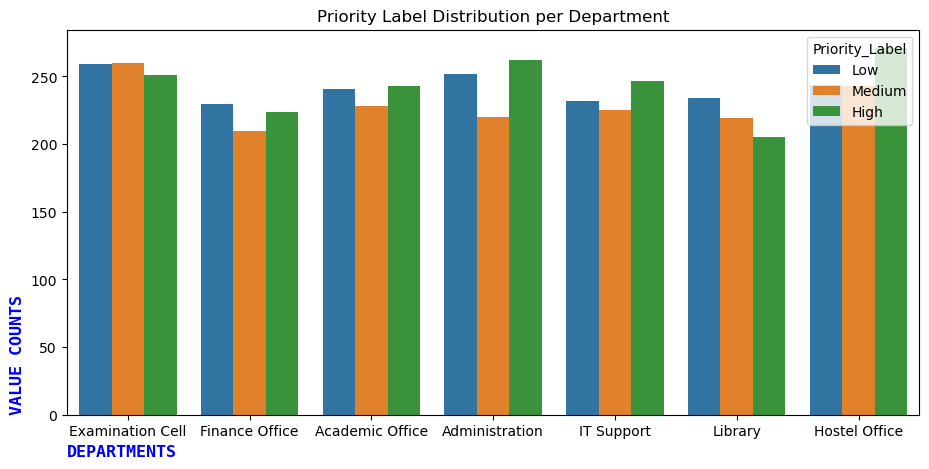

In [6]:
# Graphical Relation between Each Category in Department with Priority Label...
plt.figure(figsize=(11,5))
sns.countplot(data=Dataset,x='Department',hue='Priority_Label',hue_order=['Low','Medium','High'])
#plt.xticks(rotation=45)
plt.title('Priority Label Distribution per Department')
plt.xlabel('DEPARTMENTS',fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='left')
plt.ylabel('VALUE COUNTS',fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='bottom')
plt.show()

In [7]:
#Lowercasing...
Dataset["Student_Query"]=Dataset["Student_Query"].str.lower()
Dataset

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,how to join student clubs?,Examination Cell,31,Low
1,3918,my admit card has incorrect details.,Examination Cell,48,High
2,222,how to reset my university portal password?,Finance Office,5,Medium
3,2136,my exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,i cannot download my hall ticket for tomorrow'...,Administration,43,High
...,...,...,...,...,...
4995,4034,what are university working hours?,Academic Office,21,Low
4996,5884,fee payment deadline is today but portal is no...,Hostel Office,44,High
4997,3055,what are university working hours?,Library,24,Low
4998,1249,how to reset my university portal password?,IT Support,27,Medium


In [8]:
set(string.punctuation)

{'!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~'}

In [9]:
#Removing Punctuations...
start=time.time()
exclude=set(string.punctuation)
Dataset["Student_Query"]=Dataset["Student_Query"].apply(lambda x:''.join(ch for ch in x if ch not in exclude))
print("Time taken:",time.time()-start)
Dataset.sample(5)

Time taken: 0.0321965217590332


,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
1126,4281,fee payment deadline is today but portal is no...,Administration,9,High
3171,4929,please share syllabus for data science course,Academic Office,16,Low
4435,3964,lms is not allowing assignment upload,Administration,39,Medium
3840,1340,request for internship approval letter,Finance Office,27,Medium
1165,5369,fee payment deadline is today but portal is no...,Hostel Office,48,High


In [10]:
#Does same but a little Slower...
# start=time.time()
# Dataset["Student_Query"]=Dataset["Student_Query"].apply(lambda text: text.translate(str.maketrans('','',string.punctuation)))
# print("Time taken:",time.time()-start)
# Dataset

In [11]:
Shorty_Dictionary={
    "$" : " dollar ",
    "€" : " euro ",
    "4ao" : "for adults only",
    "a.m" : "before midday",
    "a3" : "anytime anywhere anyplace",
    "aamof" : "as a matter of fact",
    "acct" : "account",
    "adih" : "another day in hell",
    "afaic" : "as far as i am concerned",
    "afaict" : "as far as i can tell",
    "afaik" : "as far as i know",
    "afair" : "as far as i remember",
    "afk" : "away from keyboard",
    "app" : "application",
    "approx" : "approximately",
    "apps" : "applications",
    "asap" : "as soon as possible",
    "asl" : "age, sex, location",
    "atk" : "at the keyboard",
    "ave." : "avenue",
    "aymm" : "are you my mother",
    "ayor" : "at your own risk", 
    "b&b" : "bed and breakfast",
    "b+b" : "bed and breakfast",
    "b.c" : "before christ",
    "b2b" : "business to business",
    "b2c" : "business to customer",
    "b4" : "before",
    "b4n" : "bye for now",
    "b@u" : "back at you",
    "bae" : "before anyone else",
    "bak" : "back at keyboard",
    "bbbg" : "bye bye be good",
    "bbc" : "british broadcasting corporation",
    "bbias" : "be back in a second",
    "bbl" : "be back later",
    "bbs" : "be back soon",
    "be4" : "before",
    "bfn" : "bye for now",
    "blvd" : "boulevard",
    "bout" : "about",
    "brb" : "be right back",
    "bros" : "brothers",
    "brt" : "be right there",
    "bsaaw" : "big smile and a wink",
    "btw" : "by the way",
    "bwl" : "bursting with laughter",
    "c/o" : "care of",
    "cet" : "central european time",
    "cf" : "compare",
    "cia" : "central intelligence agency",
    "csl" : "can not stop laughing",
    "cu" : "see you",
    "cul8r" : "see you later",
    "cv" : "curriculum vitae",
    "cwot" : "complete waste of time",
    "cya" : "see you",
    "cyt" : "see you tomorrow",
    "dae" : "does anyone else",
    "dbmib" : "do not bother me i am busy",
    "diy" : "do it yourself",
    "dm" : "direct message",
    "dwh" : "during work hours",
    "e123" : "easy as one two three",
    "eet" : "eastern european time",
    "eg" : "example",
    "embm" : "early morning business meeting",
    "encl" : "enclosed",
    "encl." : "enclosed",
    "etc" : "and so on",
    "faq" : "frequently asked questions",
    "fawc" : "for anyone who cares",
    "fb" : "facebook",
    "fc" : "fingers crossed",
    "fig" : "figure",
    "fimh" : "forever in my heart", 
    "ft." : "feet",
    "ft" : "featuring",
    "ftl" : "for the loss",
    "ftw" : "for the win",
    "fwiw" : "for what it is worth",
    "fyi" : "for your information",
    "g9" : "genius",
    "gahoy" : "get a hold of yourself",
    "gal" : "get a life",
    "gcse" : "general certificate of secondary education",
    "gfn" : "gone for now",
    "gg" : "good game",
    "gl" : "good luck",
    "glhf" : "good luck have fun",
    "gmt" : "greenwich mean time",
    "gmta" : "great minds think alike",
    "gn" : "good night",
    "g.o.a.t" : "greatest of all time",
    "goat" : "greatest of all time",
    "goi" : "get over it",
    "gps" : "global positioning system",
    "gr8" : "great",
    "gratz" : "congratulations",
    "gyal" : "girl",
    "h&c" : "hot and cold",
    "hp" : "horsepower",
    "hr" : "hour",
    "hrh" : "his royal highness",
    "ht" : "height",
    "ibrb" : "i will be right back",
    "ic" : "i see",
    "icq" : "i seek you",
    "icymi" : "in case you missed it",
    "idc" : "i do not care",
    "idgadf" : "i do not give a damn fuck",
    "idgaf" : "i do not give a fuck",
    "idk" : "i do not know",
    "ie" : "that is",
    "i.e" : "that is",
    "ifyp" : "i feel your pain",
    "IG" : "instagram",
    "iirc" : "if i remember correctly",
    "ilu" : "i love you",
    "ily" : "i love you",
    "imho" : "in my humble opinion",
    "imo" : "in my opinion",
    "imu" : "i miss you",
    "iow" : "in other words",
    "irl" : "in real life",
    "j4f" : "just for fun",
    "jic" : "just in case",
    "jk" : "just kidding",
    "jsyk" : "just so you know",
    "l8r" : "later",
    "lb" : "pound",
    "lbs" : "pounds",
    "ldr" : "long distance relationship",
    "lmao" : "laugh my ass off",
    "lmfao" : "laugh my fucking ass off",
    "lol" : "laughing out loud",
    "ltd" : "limited",
    "ltns" : "long time no see",
    "m8" : "mate",
    "mf" : "motherfucker",
    "mfs" : "motherfuckers",
    "mfw" : "my face when",
    "mofo" : "motherfucker",
    "mph" : "miles per hour",
    "mr" : "mister",
    "mrw" : "my reaction when",
    "ms" : "miss",
    "mte" : "my thoughts exactly",
    "nagi" : "not a good idea",
    "nbc" : "national broadcasting company",
    "nbd" : "not big deal",
    "nfs" : "not for sale",
    "ngl" : "not going to lie",
    "nhs" : "national health service",
    "nrn" : "no reply necessary",
    "nsfl" : "not safe for life",
    "nsfw" : "not safe for work",
    "nth" : "nice to have",
    "nvr" : "never",
    "nyc" : "new york city",
    "oc" : "original content",
    "og" : "original",
    "ohp" : "overhead projector",
    "oic" : "oh i see",
    "omdb" : "over my dead body",
    "omg" : "oh my god",
    "omw" : "on my way",
    "p.a" : "per annum",
    "p.m" : "after midday",
    "pm" : "prime minister",
    "poc" : "people of color",
    "pov" : "point of view",
    "pp" : "pages",
    "ppl" : "people",
    "prw" : "parents are watching",
    "ps" : "postscript",
    "pt" : "point",
    "ptb" : "please text back",
    "pto" : "please turn over",
    "qpsa" : "what happens", #"que pasa",
    "ratchet" : "rude",
    "rbtl" : "read between the lines",
    "rlrt" : "real life retweet", 
    "rofl" : "rolling on the floor laughing",
    "roflol" : "rolling on the floor laughing out loud",
    "rotflmao" : "rolling on the floor laughing my ass off",
    "rt" : "retweet",
    "ruok" : "are you ok",
    "sfw" : "safe for work",
    "sk8" : "skate",
    "smh" : "shake my head",
    "sq" : "square",
    "srsly" : "seriously", 
    "ssdd" : "same stuff different day",
    "tbh" : "to be honest",
    "tbs" : "tablespooful",
    "tbsp" : "tablespooful",
    "tfw" : "that feeling when",
    "thks" : "thank you",
    "tho" : "though",
    "thx" : "thank you",
    "tia" : "thanks in advance",
    "til" : "today i learned",
    "tl;dr" : "too long i did not read",
    "tldr" : "too long i did not read",
    "tmb" : "tweet me back",
    "tntl" : "trying not to laugh",
    "ttyl" : "talk to you later",
    "u" : "you",
    "u2" : "you too",
    "u4e" : "yours for ever",
    "utc" : "coordinated universal time",
    "w/" : "with",
    "w/o" : "without",
    "w8" : "wait",
    "wassup" : "what is up",
    "wb" : "welcome back",
    "wtf" : "what the fuck",
    "wtg" : "way to go",
    "wtpa" : "where the party at",
    "wuf" : "where are you from",
    "wuzup" : "what is up",
    "wywh" : "wish you were here",
    "yd" : "yard",
    "ygtr" : "you got that right",
    "ynk" : "you never know",
    "zzz" : "sleeping bored and tired"
} 

In [12]:
Keys=set(Shorty_Dictionary.keys())
def Deshortifier(text):
    words=text.split()
    for i,word in enumerate(words):
        if word in Keys:
            words[i]=Shorty_Dictionary[word]
    return " ".join(words)
Dataset["Student_Query"]=Dataset["Student_Query"].apply(Deshortifier)
Dataset.head()

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,how to join student clubs,Examination Cell,31,Low
1,3918,my admit card has incorrect details,Examination Cell,48,High
2,222,how to reset my university portal password,Finance Office,5,Medium
3,2136,my exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,i cannot download my hall ticket for tomorrows...,Administration,43,High


In [13]:
#Spelling Correction...
# from textblob import TextBlob
# def Rectifier(text):
#     Obj=TextBlob(text)
#     return Obj.correct().string
# Dataset["Student_Query"]=Dataset["Student_Query"].apply(Rectifier)
# Dataset.sample(5)

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\siddh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
#Removing Uncessary words like Stop Words...
from nltk.corpus import stopwords
stop=set(stopwords.words("english"))
Dataset["Student_Query"]=Dataset["Student_Query"].apply(lambda x: " ".join([word for word in x.split() if word not in stop]))
Dataset.sample(5)

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
847,4353,join student clubs,IT Support,35,Low
302,5481,request internship approval letter,IT Support,39,Medium
2614,5144,request internship approval letter,Hostel Office,56,Medium
4506,3999,need bonafide certificate,Academic Office,59,Medium
2654,3045,want change elective subject,Hostel Office,35,Medium


In [16]:
#Handling Emojis...
import re
def remove_emoji(text):
    Emoji_Pattern=re.compile("["
                                u"\U0001F600-\U0001F64F" # Emoticons
                                u"\U0001F300-\U0001F5FF" # Symbols & Pictographs
                                u"\U0001F680-\U0001F6FF" # Transport & Map Symbols
                                u"\U0001F1E0-\U0001F1FF" # Flags (iOS)
                                u"\U00002702-\U000027B0" # Dingbats
                                u"\U000024C2-\U0001F251" # Enclosed Alphanumerics
                                "]+",flags=re.UNICODE)
    return Emoji_Pattern.sub(r'', text)
#This Code removes Emojis...

In [17]:
import emoji
Dataset["Student_Query"]=Dataset["Student_Query"].apply(lambda text: emoji.demojize(text))
Dataset.sample(5)

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
4600,2109,want change elective subject,IT Support,51,Medium
2753,1711,hostel application procedure,IT Support,1,Low
169,3648,admit card incorrect details,Administration,22,High
2220,2407,library issue new id cards,Finance Office,10,Low
198,4160,exam form submitted tomorrow last date,Hostel Office,32,High


In [18]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\siddh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

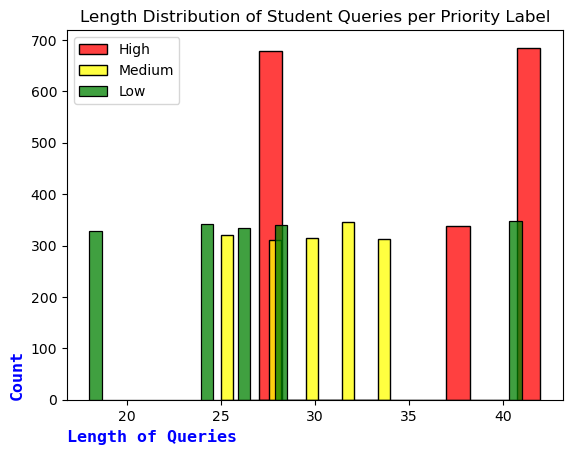

In [19]:
sns.histplot(Dataset[Dataset["Priority_Label"]=="High"]["Student_Query"].str.len(),color="red")
sns.histplot(Dataset[Dataset["Priority_Label"]=="Medium"]["Student_Query"].str.len(),color="yellow")
sns.histplot(Dataset[Dataset["Priority_Label"]=="Low"]["Student_Query"].str.len(),color="green")
plt.legend(["High","Medium","Low"])
plt.title("Length Distribution of Student Queries per Priority Label")
plt.xlabel("Length of Queries",fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='left')
plt.ylabel("Count",fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='bottom')
plt.show()

In [20]:
#Tokenization...
from nltk.tokenize import word_tokenize
Dataset["Student_Query"]=Dataset["Student_Query"].apply(word_tokenize)
Dataset.sample(5)
#Spacy Library also works great for Tokenization...Especially for mail-IDs and URLs...where word_tokenize Fails Sometimes...

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
4074,36,"[library, issue, new, id, cards]",Hostel Office,52,Low
4670,2931,"[hostel, application, procedure]",Library,57,Low
3001,3586,"[received, scholarship, amount]",IT Support,31,High
4243,2640,"[lms, allowing, assignment, upload]",IT Support,43,Medium
3242,3327,"[lms, allowing, assignment, upload]",IT Support,15,Medium


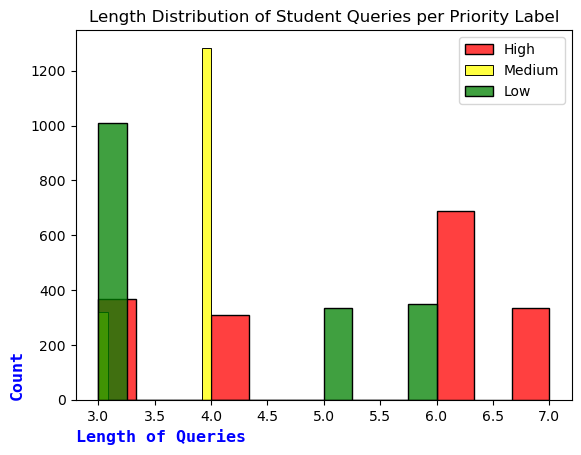

In [21]:
sns.histplot(Dataset[Dataset["Priority_Label"]=="High"]["Student_Query"].str.len(),color="red")
sns.histplot(Dataset[Dataset["Priority_Label"]=="Medium"]["Student_Query"].str.len(),color="yellow")
sns.histplot(Dataset[Dataset["Priority_Label"]=="Low"]["Student_Query"].str.len(),color="green")
plt.legend(["High","Medium","Low"])
plt.title("Length Distribution of Student Queries per Priority Label")
plt.xlabel("Length of Queries",fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='left')
plt.ylabel("Count",fontdict={'fontsize':12,'fontweight':'bold','color':'blue','fontfamily':'monospace'},loc='bottom')
plt.show()

In [22]:
#Stemming...
from nltk.stem import PorterStemmer
Stemmer=PorterStemmer()
Dataset["Student_Query"]=Dataset["Student_Query"].apply(lambda text:" ".join([Stemmer.stem(word) for word in text]))
Dataset.sample(5)

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
2046,1599,fee payment deadlin today portal work,Administration,21,High
4715,939,reset univers portal password,Hostel Office,4,Medium
2482,802,can not download hall ticket tomorrow exam,Finance Office,12,High
3273,2660,receiv scholarship amount,Academic Office,9,High
4076,2346,univers work hour,Hostel Office,60,Low


In [23]:
#Separating only Queries...
Queries=Dataset[["Student_Query"]]
type(Queries.iloc[0])

pandas.core.series.Series

In [24]:
type(Queries.iloc[1].item()) # Don't Forget the .item()

str

In [25]:
#No.of Unique Words in the Corpus...(Answer is 59 I did when PortStemmer Conversion didn't had " ".join in the End...)
Unique=set()
for i in range(Queries.shape[0]):
    for word in Queries.iloc[i].item():
        Unique.add(word)
print("No. of Unique Words in the Corpus:",len(Unique))

No. of Unique Words in the Corpus: 26


In [26]:
Queries["Student_Query"].items

<bound method Series.items of 0                                join student club
1                      admit card incorrect detail
2                    reset univers portal password
3              exam form submit tomorrow last date
4       can not download hall ticket tomorrow exam
                           ...                    
4995                             univers work hour
4996         fee payment deadlin today portal work
4997                             univers work hour
4998                 reset univers portal password
4999         fee payment deadlin today portal work
Name: Student_Query, Length: 5000, dtype: object>

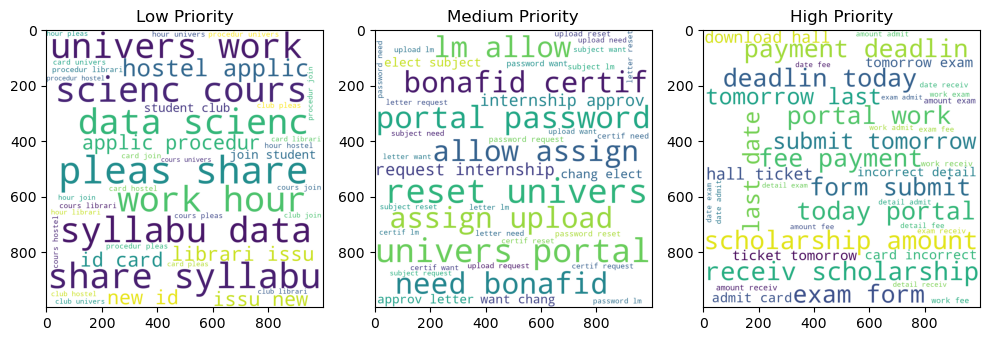

In [27]:
# Looking at Important Words/Frequently used Words in each Label...(Visual Representation)
from wordcloud import WordCloud
wc=WordCloud(width=1000,height=1000,background_color='white',min_font_size=10)

# Low_wc=wc.generate(Dataset[Dataset["Priority_Label"]=="Low"]["Student_Query"].str.cat())
# Medium_wc=wc.generate(Dataset[Dataset["Priority_Label"]=="Medium"]["Student_Query"].str.cat())
# High_wc=wc.generate(Dataset[Dataset["Priority_Label"]=="High"]["Student_Query"].str.cat())

# This won't Work Because...
# I created a single WordCloud instance called wc. 
# The .generate() method in the wordcloud library works in-place and returns self (the same object).
# Hence Do This......(Important Learning)
def get_wc(Dataset,ColName,ColTarget,RequiredCol):
    Content=Dataset[Dataset[ColName]==ColTarget][RequiredCol].str.cat(sep=' ')
    return WordCloud(width=1000,height=1000,background_color='white',min_font_size=10).generate(Content)
Low_wc=get_wc(Dataset,"Priority_Label","Low","Student_Query")
Medium_wc=get_wc(Dataset,"Priority_Label","Medium","Student_Query")
High_wc=get_wc(Dataset,"Priority_Label","High","Student_Query")

fig,axes=plt.subplots(1,3,figsize=(10,36))
axes[0].imshow(Low_wc)
axes[0].set_title("Low Priority")
axes[1].imshow(Medium_wc)
axes[1].set_title("Medium Priority")
axes[2].imshow(High_wc)
axes[2].set_title("High Priority")
fig.tight_layout()
plt.show()

In [28]:
Dataset.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [29]:
# Looking at Important Words/Frequently used Words in each Label...(Actual Words)
def Generate_Corpus(Label):
    Corpus=[]
    for Query in Dataset[Dataset["Priority_Label"]==Label]["Student_Query"].to_list():
        for word in Query.split():
            Corpus.append(word)
    return Corpus
from collections import Counter
Low=Counter(Generate_Corpus("Low")).most_common(15)
Medium=Counter(Generate_Corpus("Medium")).most_common(15)
High=Counter(Generate_Corpus("High")).most_common(15)
Temp=pd.DataFrame({"Low":Low,"Medium":Medium,"High":High})
Temp

,Low,Medium,High
0,"(pleas, 348)","(reset, 346)","(exam, 673)"
1,"(share, 348)","(univers, 346)","(tomorrow, 673)"
2,"(syllabu, 348)","(portal, 346)","(receiv, 369)"
3,"(data, 348)","(password, 346)","(scholarship, 369)"
4,"(scienc, 348)","(need, 321)","(amount, 369)"
5,"(cours, 348)","(bonafid, 321)","(fee, 351)"
6,"(univers, 341)","(certif, 321)","(payment, 351)"
7,"(work, 341)","(lm, 314)","(deadlin, 351)"
8,"(hour, 341)","(allow, 314)","(today, 351)"
9,"(hostel, 340)","(assign, 314)","(portal, 351)"


##### We will now decide what to use CountVectorizer or TfidfVectorizer...

In [30]:
Queries.columns

Index(['Student_Query'], dtype='object')

In [31]:
Queries["Student_Query"]

0                                join student club
1                      admit card incorrect detail
2                    reset univers portal password
3              exam form submit tomorrow last date
4       can not download hall ticket tomorrow exam
                           ...                    
4995                             univers work hour
4996         fee payment deadlin today portal work
4997                             univers work hour
4998                 reset univers portal password
4999         fee payment deadlin today portal work
Name: Student_Query, Length: 5000, dtype: object

In [32]:
# ngram_range len(Vectorizer.vocabulary_)
#   (1,1)            59
#   (2,2)            50
#   (3,3)            35
#   (1,2)            109
#   (1,3)            144
#   (2,3)            85
from sklearn.feature_extraction.text import CountVectorizer
Vectorizer=CountVectorizer(ngram_range=(3,3),lowercase=False)
Vectorized_Queries=Vectorizer.fit_transform(Queries["Student_Query"]).toarray()
print(len(Vectorizer.vocabulary_))
print(Vectorized_Queries.shape)

35
(5000, 35)


In [33]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# Vectorizer=TfidfVectorizer(ngram_range=(3,3),lowercase=False)
# Vectorized_Queries=Vectorizer.fit_transform(Queries["Student_Query"]).toarray()
# print(len(Vectorizer.vocabulary_))
# print(Vectorized_Queries.shape)

In [34]:
Dataset.columns

Index(['Query_ID', 'Student_Query', 'Department', 'Days_To_Deadline',
       'Priority_Label'],
      dtype='object')

In [35]:
Dataset["Student_Query"]=list(Vectorized_Queries)
Dataset.sample(5)

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
3423,2160,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Hostel Office,12,Medium
2951,4950,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Academic Office,60,High
1765,1504,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",Hostel Office,46,High
1225,4770,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",Administration,42,Medium
2270,5876,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Academic Office,49,High


In [36]:
Dataset.drop("Query_ID",axis=1,inplace=True)
Dataset.head()

,Student_Query,Department,Days_To_Deadline,Priority_Label
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Examination Cell,31,Low
1,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Examination Cell,48,High
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Finance Office,5,Medium
3,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",Academic Office,18,High
4,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...",Administration,43,High


In [37]:
Department_Encoded=pd.get_dummies(Dataset['Department'],drop_first=True)
Dataset=pd.concat([Dataset,Department_Encoded],axis=1)
Dataset.drop('Department',axis=1,inplace=True)
Dataset['Priority_Label']=Dataset['Priority_Label'].map({'High':3,'Medium':2,'Low':1})
Dataset.head()

,Student_Query,Days_To_Deadline,Priority_Label,Administration,Examination Cell,Finance Office,Hostel Office,IT Support,Library
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",31,1,False,True,False,False,False,False
1,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",48,3,False,True,False,False,False,False
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,2,False,False,True,False,False,False
3,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",18,3,False,False,False,False,False,False
4,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...",43,3,True,False,False,False,False,False


#### Making Clean Pipeline for Data Tranformation, Training and to Keep Code Deployable... 

In [38]:
from sklearn.compose import ColumnTransformer
Dataset=pd.read_csv("university_query_train.csv")
Query_Transformer=ColumnTransformer([
    
],remainder="passthrough")